# Reservoir Computing (RC) 이란?

- Reservoir: 저수지
    
    → Reservoir Computing 분야에서 사용되는 모델(네트워크)의 본체이며, 쉽게 말해 **외부의 자극에 대해 어떤 ‘반응’을 리턴하는, low-dimension to high-dimension 매핑.**
    
    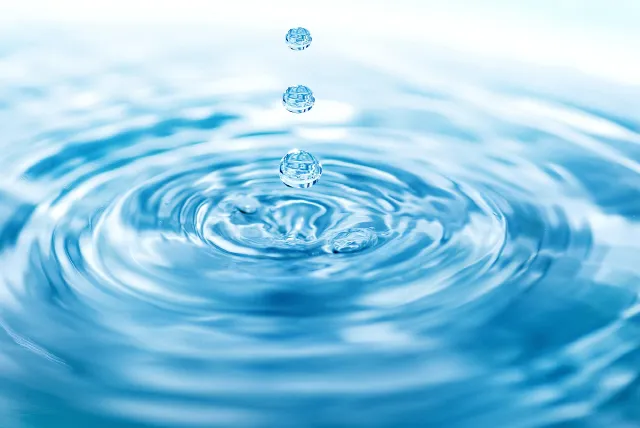
    
    → 물 표면에 각기 다른 순서와 모양의 input (ex: 돌멩이)을 순차적으로 떨어뜨리면, 조합에 따라 unique한 모양의 파동이 생김.
    
- **쉽게 말해, 모델의 state가 input에 대해 반응하는 형태를 이용해 computing을 수행하는 분야**

# Echo State Network (ESN)

[“**Harnessing Nonlinearity: Predicting Chaotic Systems and Saving Energy in Wireless Communication”, H. Jaeger, et. al.**](https://www.science.org/doi/abs/10.1126/science.1091277)

논문 제목에 Saving Energy가 들어가 있을 만큼 구현 효율이 좋다.

- 개요: Reservoir를 Recurrent network를 사용해 구현한 것.
    - Echo state property: 요약하자면 메아리처럼 state가 시간에 따라 천천히 요동하며 fading out 하는 것.
        
        > … which means that the effect of the initial conditions and its internal perturbation should vanish as time passes …
        >

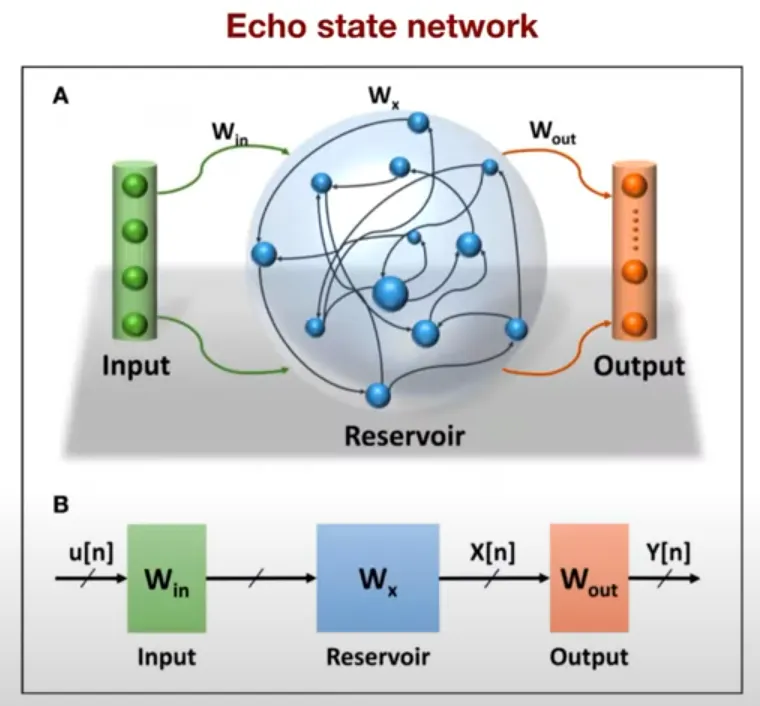

- Echo State Network의 수식
$$\mathbf{s}_{t+1} = (1-\alpha)\mathbf{s}_t + \alpha\,\textrm{tanh}(\mathbf{Ws}_t + \mathbf{W}_{\mathrm{in}}\mathbf{u}_t +  \boldsymbol{\xi})$$

- $\mathbf{W}\in\mathbb{R}^{N\times N}$: reservoir의 연결 특성을 나타내는 `weigths`
- $\mathbf{s}_t\in\mathbb{R}^N$: 시간 $t$ 초의 reservoir state (reservoir의 ‘표면 상태’ 로 이해할 수 있음)
- $\alpha\in\mathbb{R}$: State-decay coefficient (Echo state property를 모델링)
- $\mathbf{u}_t\in\mathbb{R}^{d}$: 시간 $t$ 초에 reservoir에 주입 되는 `input_signal` (즉, ‘돌멩이’)
- $\mathbf{W}_{\mathrm{in}}\in\mathbb{R}^{N\times d}$: input $u_t\in\mathbb{R}^{d}$를 state에 전달하는 데에 쓰이는 `read_in` weights
- $\boldsymbol{\xi}\in\mathbb{R}^N$: random bias

# 시계열 훈련 및 예측생성 방법

1. input signal(돌멩이)를 지속적으로 reservoir (물 표면)에 주입하며, 그 동안 관찰된 reservoir 의 state (파동의 모양)을 계속 기록해둔다.
    - 좀 더 명확하게, $t$ 초의 state와  $t$ 초에 들어갈 input을 쌍으로 매핑하여 기록한다. 
2. 모든 state 들의 기록 (state record)을 $\mathbf{S}\in\mathbb{R}^{N\times T}$,이라 하고, 해당 기록을 모으는 데 사용한 input signal을 $\mathbf{U}_{\mathrm{train}}\in\mathbb{R}^{d\times T}$라 하자.
3. 다음을 만족하는 적절한 매핑 $\phi:\mathbb{R}^{N}\to\mathbb{R}^{d}$를 찾는다.
    
    $$
    \mathbf{U}_{\mathrm{train}}[:,\,t] \simeq\phi(\mathbf{S}[:,\,t]), \;\;\forall t
    $$
    
    즉, 시간 $t$ 초에서의 data prediction은 $\phi(\mathbf{S}[:,\,t])$로 정의한다.
    
4. 3에서 찾은 적절한 매핑 $\phi$를 이용하여, 훈련이 끝난 단계 바로 다음부터는 아래와 같이 reservoir state를 업데이트하며 $\phi(\mathrm{s}_{t+1})$를 prediction으로 사용한다.
    
    $$
    \mathbf{s}_{t+1} = (1-\alpha)\mathbf{s}_t +  \alpha\,\tanh(\mathbf{Ws}_t + \mathbf{W}_{\mathrm{in}}\phi(\mathbf{s}_t) +  \boldsymbol{\xi})
    $$
    
    즉, 이제부터는 훈련단계의 인풋을 넣어주지 않으므로 $\mathbf{u}_t \simeq\phi(\mathbf{s}_t)$ 근사를 이용한 것 뿐이다.
    

→ 그렇다면, 매핑 $\phi$를 찾는 가장 간단한 방법은?

# Pseudo Inverse (유사 역행렬)

Moore-Penrose inverse라고도 불린다. 

- 즉, **해당 매핑 $\phi$를 어떤 linear transform $\boldsymbol{\Phi}$로 가정하면**, 두 행렬 $\mathbf{S}\in\mathbb{R}^{N\times T},\;\mathbf{U} \in \mathbb{R}^{d\times T}$에 대해, 다음 식을 푸는 상황과 같다.
    
    $$
    \mathrm{argmin}_{\boldsymbol{\Phi}}\frac{1}{N}\sum_{t=1}^T ||\boldsymbol\Phi(\mathbf{S}[:,\,t]) - \mathbf{U}[:,\,t]||_2=\mathrm{argmin}_{\boldsymbol{\Phi}}||\boldsymbol{\Phi}\mathbf{S} - \mathbf{U}||_{\mathrm{F}}
    $$
    
    → 다시 말해서, $\boldsymbol{\Phi}\mathbf{S} \simeq \mathbf{U}$를 최대한 만족하는 $\boldsymbol{\Phi}$를 찾는 것.
    
- 이 때, 해당 선형변환 $\boldsymbol\Phi:\mathbb{R}^{d\times N}$은, 다음과 같이 유일하게 계산할 수 있다:
    
    $$
    \begin{align}\boldsymbol\Phi & = \mathbf{U}\mathbf{S}^{+}\\ & = \mathbf{U}(\mathbf{S}^\top\mathbf{S})^{-1}\mathbf{S}^\top\end{align}
    $$
    
    여기서, $\mathbf{S}^+ := (\mathbf{S}^\top\mathbf{S})^{-1}\mathbf{S}^\top$가 바로 $\mathbf{S}$의 pseudo inverse이다.

In [13]:
import numpy as np
import torch

from rc.dynamical_systems import LorenzSystem, RosslerSystem
from rc.esn import EchoStateNetwork
from rc.nn import ReadOutNN
from rc.utils import get_error, plot_3d_trajectory_matplotlib

Chatoic lorenz system 궤적 준비

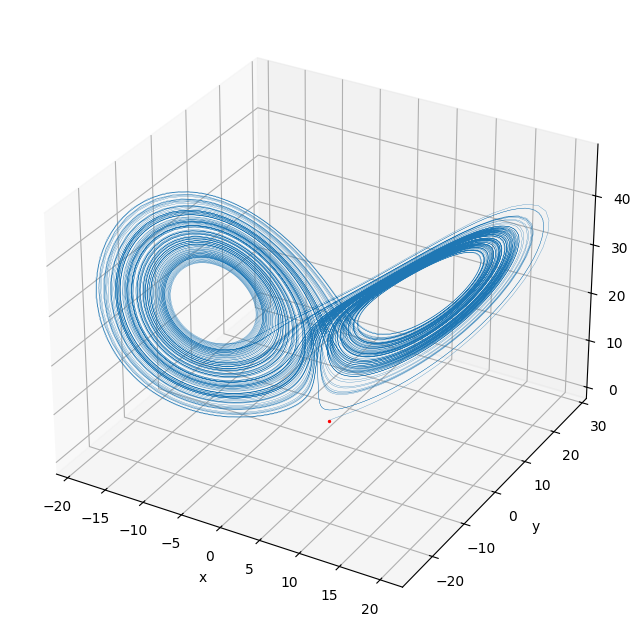

In [15]:
lorenz_system = LorenzSystem(rho=28, sigma=10, beta=10/3)
traj = lorenz_system.solve_trajectory(
    x0=np.array([1, 1, 1]).astype(float),  # 초기 조건
    t_fin=500,  # 해를 구할 최종 시간
    dt=0.01,  # 시간 증분
)
plot_3d_trajectory_matplotlib(traj[:15000], linewidth=0.2)

In [16]:
len(traj)

50001

적절히 해의 궤적(traj)을 샘플링하여 훈련 및 예측할 시계열 준비

In [17]:
traj_sampled: np.ndarray = traj[::3]
traj_sampled = traj_sampled + 0.001 * np.random.randn(*traj_sampled.shape)  # 데이터에 랜덤 노이즈 추가 과정
init_run = 1000  # 인풋 시그널을 esn에 주지만, state를 모으지는 않을 iteration 횟수
train_len = 10000  # 훈련에 사용할 시계열 길이
train_input = traj_sampled[:train_len]  # 훈련 시계열
train_target = traj_sampled[init_run:train_len]  # state-record를 모으기 시작한 순간부터의 훈련 시계열
target = traj_sampled[train_len: train_len + 2500]  # 생성 검증에 사용할 시계열 길이

ESN 준비

In [18]:
esn = EchoStateNetwork(
    num_nodes=500,  # ESN의 RNN 노드 수
    weight_connection_prob=0.2,  # weight 연결 확률
    rho=0.2,  # weight 평균 세기
    increment=0.05,  # Echo-State-Property를 만족하기 위한 decaying rate
    bias=0.2,  # 바이어스 상수
    read_in_mul=0.2,
)
state_records, weights_in = esn.record_state(  # state_records: 관찰한 state
    pre_run=1000,  # 인풋 없이 도는 iteration 횟수
    init_run=init_run,
    input_data=train_input,
)

In [19]:
state_records.shape

(9000, 500)

In [ ]:
# training read_out via pseudo-inverse
read_out = np.linalg.pinv(state_records) @ train_target  # 마법의 한 줄 (phi 매핑)
train_err = get_error(x1=state_records @ read_out, x2=train_target, order="fro", plot=False)

	Error: 0.193874
Train Error: 0.193874


생성한 뒤 target과 비교

	Error: 1076.372649


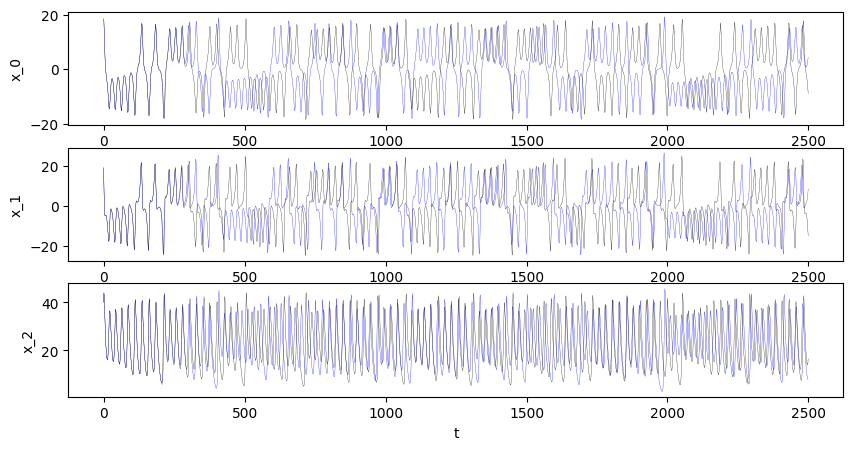

Prediction Error: 1076.372649


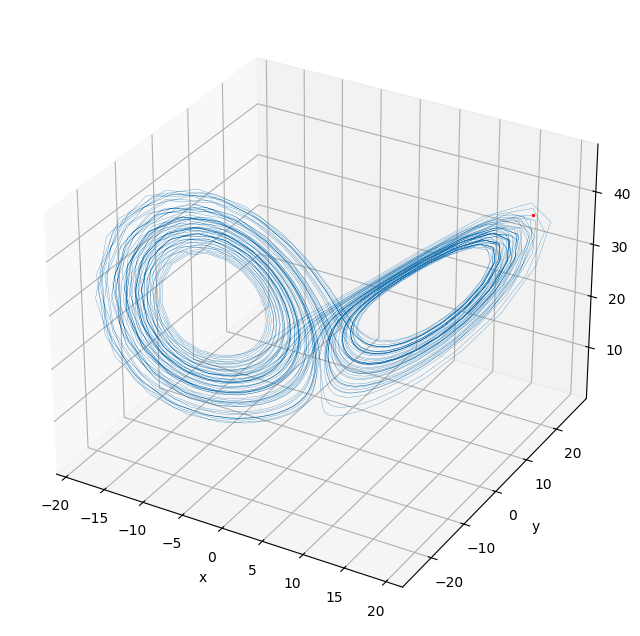

In [21]:
predicted = esn.predict(
    steps=len(target),
    weights_in=weights_in,
    weights_out=read_out,
)
pred_err = get_error(x1=predicted, x2=target, order="fro")
print(f"Prediction Error: {pred_err:.6f}")
plot_3d_trajectory_matplotlib(predicted)

### 또는, Pseudo Inverse 대신 아래와 같이 Neural Net을 이용하여 직접 `read_out`을 피팅할 수 있다.

Epoch 1999 loss: 0.010516
	Error: 1149.385378


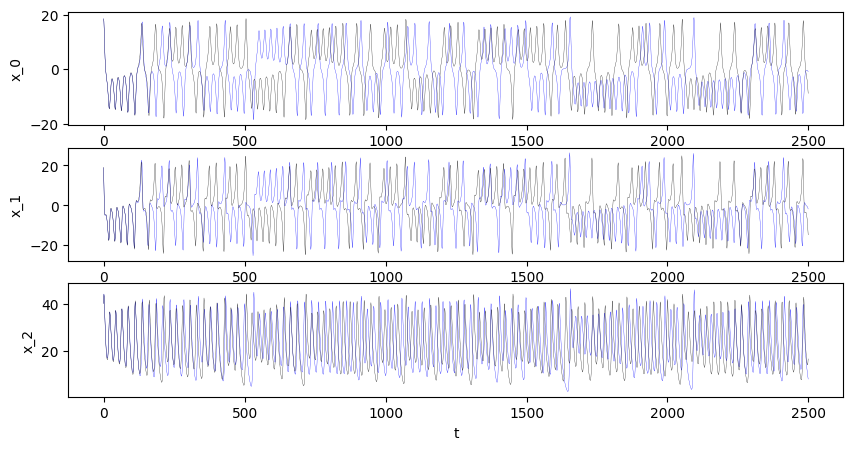

Prediction Error: 1149.385378


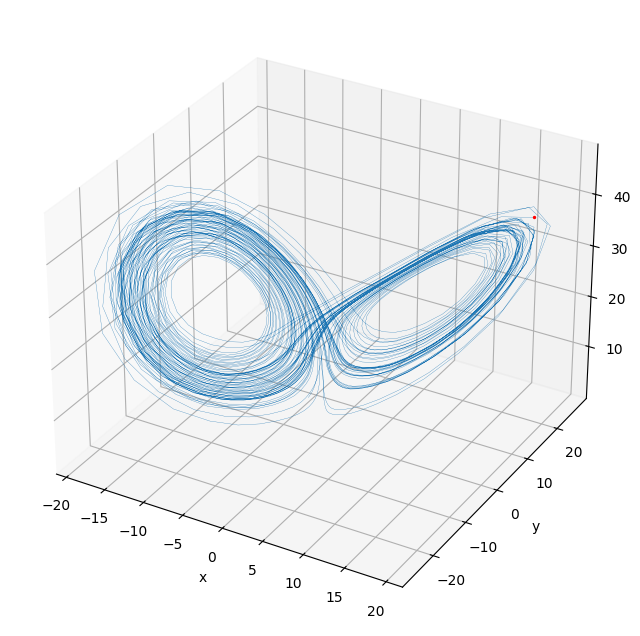

In [22]:
esn = EchoStateNetwork(
    num_nodes=500,
    weight_connection_prob=0.1,
    rho=0.2,
    increment=0.1,
    bias=0.2,
    read_in_mul=0.2,
)
state_records, weights_in = esn.record_state(
    pre_run=1000,
    init_run=init_run,
    input_data=train_input,
)

# training read-out via NN
device = torch.device("cuda:3")
read_out = ReadOutNN(
    input_dim=esn.num_nodes,
    inner_d=500,
    drop_p=0.0,
    output_dim=traj.shape[1],
).to(device)
read_out.train_target(
    input=torch.from_numpy(state_records).float().to(device),
    target=torch.from_numpy(train_target).float().to(device),
    epochs=2000,
    lr=0.01,
)
read_out.eval()

# NN으로 구성한 read-out을 생성에 사용
predicted = esn.predict(
    steps=len(target),
    weights_in=weights_in,
    weights_out=read_out,
    device=device,
)
pred_err = get_error(x1=predicted, x2=target, order="fro")
print(f"Prediction Error: {pred_err:.6f}")

plot_3d_trajectory_matplotlib(predicted)

Rossler 시스템의 궤적도 예측해보기

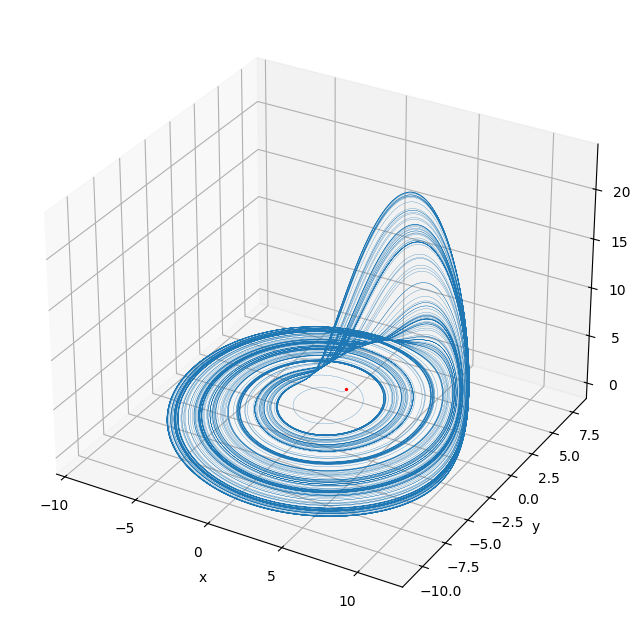

In [24]:
rossler_system = RosslerSystem(a=0.2, b=0.2, c=5.7)
traj = rossler_system.solve_trajectory(
    x0=np.array([1, 1, 1]).astype(float),
    t_fin=1000,
    dt=0.01,
)
plot_3d_trajectory_matplotlib(traj, linewidth=0.2)

	Error: 0.015930
Train Error: 0.015930
	Error: 334.580496


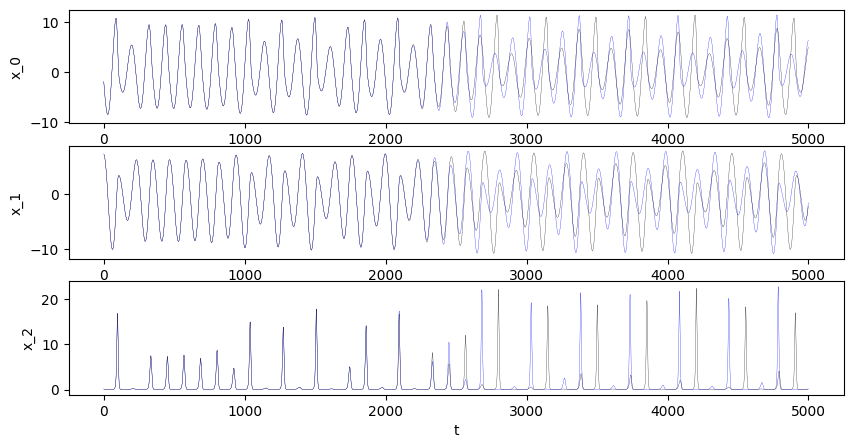

Prediction Error: 334.580496


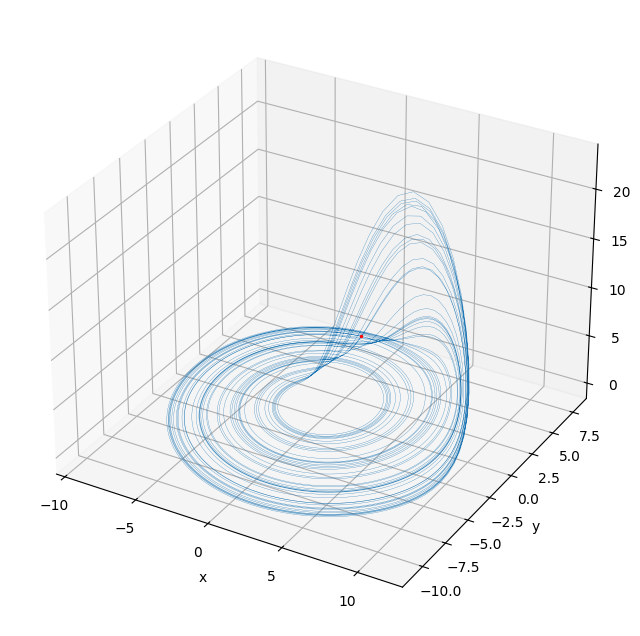

In [25]:
# 적당히 샘플링하고 잘라서 train & target 시계열 확보
traj_sampled: np.ndarray = traj[::5]
traj_sampled = traj_sampled + 0.0001 * np.random.randn(*traj_sampled.shape)
init_run = 1000
train_len = 10000
train_input = traj_sampled[:train_len]
train_target = traj_sampled[init_run:train_len]
target = traj_sampled[train_len: train_len + 5000]

esn = EchoStateNetwork(
    num_nodes=500,
    weight_connection_prob=0.2,
    rho=0.2,
    increment=0.05,
    bias=0.2,
    read_in_mul=0.2,
)
state_records, weights_in = esn.record_state(
    pre_run=1000,
    init_run=init_run,
    input_data=train_input,
)

# training read_out via pseudo-inverse
read_out = np.linalg.pinv(state_records) @ train_target
train_err = get_error(x1=state_records @ read_out, x2=train_target, order="fro", plot=False)
print(f"Train Error: {train_err:.6f}")

predicted = esn.predict(
    steps=len(target),
    weights_in=weights_in,
    weights_out=read_out,
)
pred_err = get_error(x1=predicted, x2=target, order="fro")
print(f"Prediction Error: {pred_err:.6f}")
plot_3d_trajectory_matplotlib(predicted)

Epoch 1999 loss: 0.003089
	Error: 736.975643


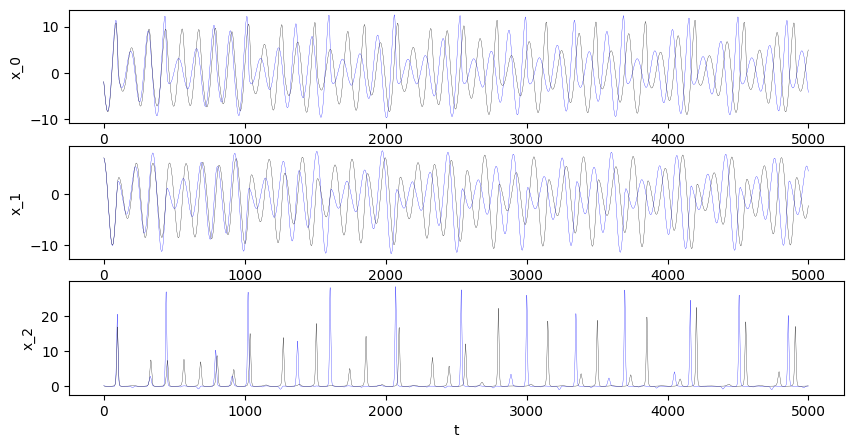

Prediction Error: 736.975643


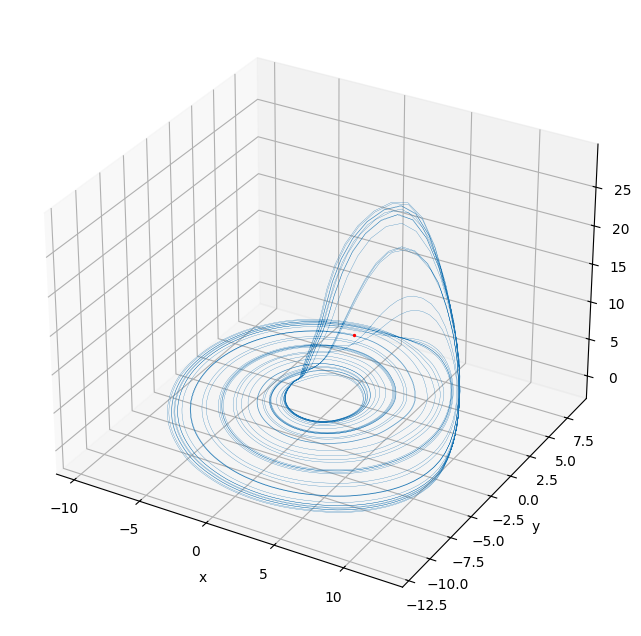

In [26]:
# rossler 시스템의 궤적도 NN을 사용하여 예측
esn = EchoStateNetwork(
    num_nodes=500,
    weight_connection_prob=0.1,
    rho=0.2,
    increment=0.1,
    bias=0.2,
    read_in_mul=0.2,
)
state_records, weights_in = esn.record_state(
    pre_run=1000,
    init_run=init_run,
    input_data=train_input,
)

device = torch.device("cuda:3")
read_out = ReadOutNN(
    input_dim=esn.num_nodes,
    inner_d=500,
    drop_p=0.0,
    output_dim=traj.shape[1],
).to(device)
read_out.train_target(
    input=torch.from_numpy(state_records).float().to(device),
    target=torch.from_numpy(train_target).float().to(device),
    epochs=2000,
    lr=0.01
)
read_out.eval()

predicted = esn.predict(
    steps=len(target),
    weights_in=weights_in,
    weights_out=read_out,
    device=device,
)
pred_err = get_error(x1=predicted, x2=target, order="fro")
print(f"Prediction Error: {pred_err:.6f}")

plot_3d_trajectory_matplotlib(predicted)